# Chapter 20 — Logistic Regression

## Learning Objectives

By the end of this chapter, you will be able to:

- Explain why ordinary linear regression is not ideal for a binary outcome
- Understand probability, odds, and log-odds
- Explain the logistic function
- Write a logistic regression model
- Fit logistic regression with `statsmodels`
- Interpret coefficients using odds ratios
- Calculate predicted probabilities
- Convert probabilities into class predictions using a threshold
- Build and interpret a confusion matrix
- Calculate accuracy, precision, recall, and specificity
- Understand why the classification threshold is a decision choice
- Interpret coefficient confidence intervals and hypothesis tests
- Avoid unsupported causal interpretations


## 1. From Linear Regression to Logistic Regression

Chapters 18 and 19 modeled a **quantitative outcome** such as performance score.

Now suppose the outcome has only two possible values:

$$
Y \in \{0,1\}
$$

For this chapter:

- $Y=1$: promoted
- $Y=0$: not promoted

Instead of directly predicting a numerical score, we want to model the **probability** of promotion.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root containing a data/ directory.")

ROOT = find_project_root(Path.cwd())
DATA_PATH = ROOT / "data" / "20_logistic_regression.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,employee_id,training_hours,experience_years,project_load,promoted
0,E001,10.9,2.1,5,0
1,E002,6.4,13.8,7,1
2,E003,12.1,3.8,6,1
3,E004,9.9,1.0,4,0
4,E005,1.8,8.5,6,1


## 2. Dataset

The dataset contains **160 fictional employees**.

| Variable | Role | Description |
|---|---|---|
| `employee_id` | ID | Fictional employee identifier |
| `training_hours` | Predictor | Training hours |
| `experience_years` | Predictor | Years of work experience |
| `project_load` | Predictor | Number of active projects |
| `promoted` | Binary outcome | 1 = promoted, 0 = not promoted |

All data are synthetic and are used only for statistical learning.


In [2]:
df.describe()


,training_hours,experience_years,project_load,promoted
count,160.000000,160.000000,160.000000,160.000000
mean,7.118125,7.462500,4.256250,0.331250
std,3.699224,4.337271,2.016432,0.472141
min,0.600000,0.700000,1.000000,0.000000
25%,4.100000,3.700000,3.000000,0.000000
50%,6.950000,7.150000,4.000000,0.000000
75%,10.200000,11.800000,6.000000,1.000000
max,13.700000,14.900000,7.000000,1.000000


In [3]:
df["promoted"].value_counts().sort_index()


promoted
0    107
1     53
Name: count, dtype: int64

In [4]:
df["promoted"].value_counts(normalize=True).sort_index()


promoted
0    0.66875
1    0.33125
Name: proportion, dtype: float64

## 3. Why Not Use Ordinary Linear Regression?

A binary outcome contains only 0 and 1.

If we apply an ordinary straight-line model directly, predicted values can theoretically fall below 0 or above 1.

But probabilities must satisfy

$$
0 \le p \le 1
$$

Logistic regression solves this by modeling probability through an S-shaped transformation.


## 4. Probability and Odds

Let

$$
p = P(Y=1)
$$

The **odds** of the event are

$$
\text{Odds} = \frac{p}{1-p}
$$

Examples:

- if $p=0.50$, odds = 1
- if $p=0.75$, odds = 3
- if $p=0.20$, odds = 0.25

Odds compare the probability that the event occurs with the probability that it does not occur.


In [5]:
example_probabilities = np.array([0.20, 0.50, 0.75])
example_odds = example_probabilities / (1 - example_probabilities)

pd.DataFrame({
    "probability": example_probabilities,
    "odds": example_odds,
})


,probability,odds
0,0.20,0.25
1,0.50,1.00
2,0.75,3.00


## 5. From Odds to Log-Odds

Odds range from 0 to infinity.

Taking the natural logarithm gives the **log-odds**, or **logit**:

$$
\operatorname{logit}(p)
=
\log\left(\frac{p}{1-p}\right)
$$

Log-odds can range from negative infinity to positive infinity.

Logistic regression models these log-odds as a linear combination of predictors.


In [6]:
example_log_odds = np.log(example_odds)

pd.DataFrame({
    "probability": example_probabilities,
    "odds": example_odds,
    "log_odds": example_log_odds,
})


,probability,odds,log_odds
0,0.20,0.25,-1.386294
1,0.50,1.00,0.000000
2,0.75,3.00,1.098612


## 6. The Logistic Regression Model

With multiple predictors, logistic regression is written as

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0
+
\beta_1X_1
+
\beta_2X_2
+
\cdots
+
\beta_kX_k
$$

In this chapter:

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0
+
\beta_1(\text{Training})
+
\beta_2(\text{Experience})
+
\beta_3(\text{Project Load})
$$

The left side is log-odds.

The right side is linear in the predictors.


## 7. The Logistic Function

To convert a linear predictor back into a probability, use the logistic function.

Let

$$
z
=
\beta_0
+
\beta_1X_1
+
\cdots
+
\beta_kX_k
$$

Then

$$
p
=
\frac{1}{1+e^{-z}}
$$

No matter how large or small $z$ becomes, the resulting probability stays between 0 and 1.


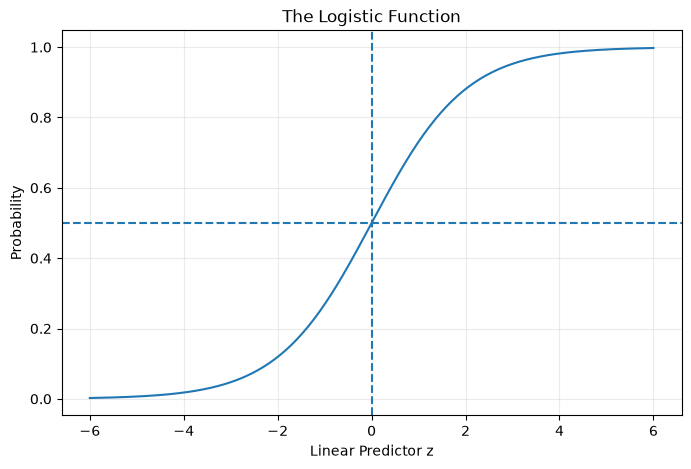

In [7]:
z = np.linspace(-6, 6, 300)
p = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 5))
plt.plot(z, p)
plt.axhline(0.5, linestyle="--")
plt.axvline(0, linestyle="--")
plt.xlabel("Linear Predictor z")
plt.ylabel("Probability")
plt.title("The Logistic Function")
plt.grid(alpha=0.25)
plt.show()


Notice the S-shaped curve:

- very negative $z$ gives probability near 0
- $z=0$ gives probability 0.5
- very positive $z$ gives probability near 1

The relationship between predictors and **log-odds** is linear, but the relationship between predictors and **probability** is nonlinear.


## 8. Explore the Binary Outcome

A useful first step is to compare predictor distributions across the two outcome groups.


In [8]:
df.groupby("promoted")[
    ["training_hours", "experience_years", "project_load"]
].mean()


,training_hours,experience_years,project_load
promoted,,,
0,6.114019,6.581308,4.598131
1,9.145283,9.241509,3.566038


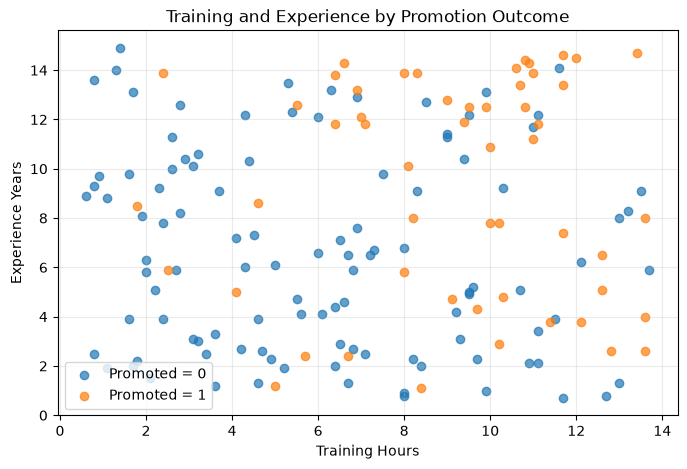

In [9]:
plt.figure(figsize=(8, 5))

for outcome in [0, 1]:
    subset = df[df["promoted"] == outcome]
    plt.scatter(
        subset["training_hours"],
        subset["experience_years"],
        label=f"Promoted = {outcome}",
        alpha=0.7,
    )

plt.xlabel("Training Hours")
plt.ylabel("Experience Years")
plt.title("Training and Experience by Promotion Outcome")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


Exploratory plots can reveal patterns, but overlapping groups are completely normal.

Logistic regression does not require the two groups to be perfectly separated.


## 9. Fit the Logistic Regression Model

We use `statsmodels.Logit`.

As before, we add an intercept explicitly.


In [10]:
X = df[["training_hours", "experience_years", "project_load"]]
X = sm.add_constant(X)

y = df["promoted"]

model = sm.Logit(y, X).fit()
print(model.summary())


Optimization terminated successfully.
         Current function value: 0.490741
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               promoted   No. Observations:                  160
Model:                          Logit   Df Residuals:                      156
Method:                           MLE   Df Model:                            3
Date:                Sun, 20 Sep 2026   Pseudo R-squ.:                  0.2273
Time:                        16:41:56   Log-Likelihood:                -78.519
converged:                       True   LL-Null:                       -101.61
Covariance Type:            nonrobust   LLR p-value:                 5.188e-10
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -2.9376      0.760     -3.865      0.000      -4.427      -1.448
training_ho

The fitted coefficients describe changes in **log-odds**, holding the other included predictors constant.

This scale is mathematically useful but often difficult to interpret directly.

That is why logistic regression coefficients are commonly converted into **odds ratios**.


## 10. From Coefficients to Odds Ratios

For a coefficient $b_j$, the corresponding odds ratio is

$$
OR_j = e^{b_j}
$$

An odds ratio compares the odds after a one-unit increase in the predictor with the odds before that increase, holding the other included predictors constant.


In [11]:
odds_ratios = np.exp(model.params)

pd.DataFrame({
    "coefficient": model.params,
    "odds_ratio": odds_ratios,
})


,coefficient,odds_ratio
const,-2.937626,0.052991
training_hours,0.254812,1.290218
experience_years,0.166784,1.181499
project_load,-0.250000,0.778800


### Interpreting an Odds Ratio

For a quantitative predictor:

- $OR>1$: the odds increase as the predictor increases
- $OR<1$: the odds decrease as the predictor increases
- $OR=1$: no change in odds for a one-unit increase

For example, if an odds ratio were 1.25, a one-unit increase in the predictor would multiply the odds by 1.25, holding the other predictors constant.

That corresponds to a **25% increase in the odds**, not necessarily a 25-percentage-point increase in probability.


## 11. Odds Are Not Probabilities

This distinction is essential.

Suppose the odds ratio is 2.

That means the **odds** are multiplied by 2.

It does not mean:

- the probability doubles
- the probability increases by 100 percentage points
- the event becomes certain

Because the logistic transformation is nonlinear, the same odds ratio can correspond to different probability changes depending on the starting probability.


## 12. Predicted Probabilities

The fitted model can estimate

$$
\hat{p}_i = P(Y_i=1 \mid X_i)
$$

for every observation.


In [12]:
df["predicted_probability"] = model.predict(X)

df[
    [
        "employee_id",
        "training_hours",
        "experience_years",
        "project_load",
        "promoted",
        "predicted_probability",
    ]
].head(10)


,employee_id,training_hours,experience_years,project_load,promoted,predicted_probability
0,E001,10.9,2.1,5,0,0.257322
1,E002,6.4,13.8,7,1,0.319686
2,E003,12.1,3.8,6,1,0.327254
3,E004,9.9,1.0,4,0,0.223010
4,E005,1.8,8.5,6,1,0.071671
5,E006,13.7,5.9,3,0,0.687255
6,E007,10.8,12.5,4,1,0.710772
7,E008,11.1,12.2,4,0,0.716171
8,E009,2.2,5.1,7,0,0.036388
9,E010,6.6,14.3,6,1,0.408333


In [13]:
df["predicted_probability"].describe()


count    160.000000
mean       0.331250
std        0.246835
min        0.016456
25%        0.120902
50%        0.250790
75%        0.542960
max        0.902799
Name: predicted_probability, dtype: float64

A predicted probability is a continuous value between 0 and 1.

At this stage, the model has produced probabilities — **not class labels**.


## 13. Visualizing Predicted Probability

To isolate the relationship with training hours, hold the other predictors at fixed values.

Here we use their sample means.


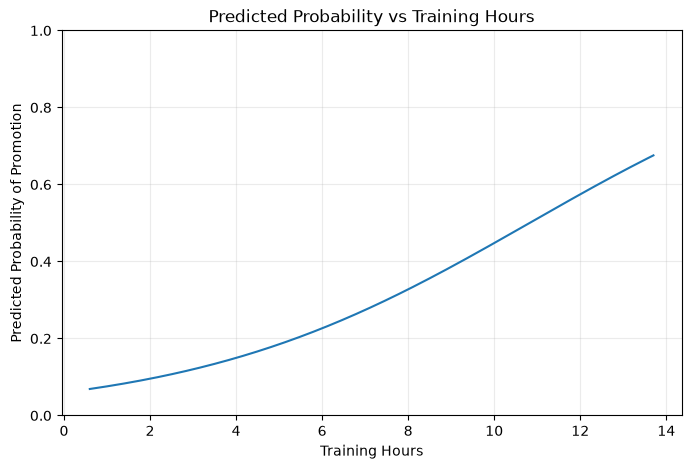

In [14]:
training_grid = np.linspace(
    df["training_hours"].min(),
    df["training_hours"].max(),
    200,
)

prediction_grid = pd.DataFrame({
    "const": 1.0,
    "training_hours": training_grid,
    "experience_years": df["experience_years"].mean(),
    "project_load": df["project_load"].mean(),
})

probability_grid = model.predict(prediction_grid)

plt.figure(figsize=(8, 5))
plt.plot(training_grid, probability_grid)
plt.xlabel("Training Hours")
plt.ylabel("Predicted Probability of Promotion")
plt.title("Predicted Probability vs Training Hours")
plt.ylim(0, 1)
plt.grid(alpha=0.25)
plt.show()


Unlike ordinary linear regression, the change in probability per additional training hour is not constant across the entire curve.

The coefficient is constant on the **log-odds scale**, not on the probability scale.


## 14. Confidence Intervals for Odds Ratios

The coefficient confidence intervals are on the log-odds scale.

Exponentiating them gives confidence intervals for odds ratios.


In [15]:
coef_ci = model.conf_int()

or_table = pd.DataFrame({
    "odds_ratio": np.exp(model.params),
    "lower_95": np.exp(coef_ci[0]),
    "upper_95": np.exp(coef_ci[1]),
})

or_table


,odds_ratio,lower_95,upper_95
const,0.052991,0.011945,0.235086
training_hours,1.290218,1.149637,1.447991
experience_years,1.181499,1.078424,1.294426
project_load,0.778800,0.643019,0.943254


For an odds ratio, the null value is

$$
OR=1
$$

because multiplying odds by 1 means no change.

An interval that excludes 1 corresponds to evidence against a zero coefficient under the model assumptions.


## 15. Hypothesis Tests for Coefficients

For predictor $X_j$, a common test is

$$
H_0:\beta_j=0
$$

versus

$$
H_1:\beta_j\ne0
$$

`statsmodels` reports coefficient estimates, standard errors, test statistics, and p-values.


In [16]:
coefficient_table = pd.DataFrame({
    "coefficient": model.params,
    "std_error": model.bse,
    "z_statistic": model.tvalues,
    "p_value": model.pvalues,
})

coefficient_table


,coefficient,std_error,z_statistic,p_value
const,-2.937626,0.760127,-3.864653,0.000111
training_hours,0.254812,0.058861,4.329038,0.000015
experience_years,0.166784,0.046574,3.581047,0.000342
project_load,-0.250000,0.097747,-2.557622,0.010539


A small p-value provides evidence against a zero conditional coefficient under the model assumptions.

It does not establish:

- causation
- practical importance
- good predictive performance
- correct model specification


## 16. From Probability to a Class Prediction

A probability can be converted into a class using a threshold.

For example, with threshold 0.5:

$$
\hat{Y}
=
\begin{cases}
1 & \text{if } \hat{p}\ge0.5 \\
0 & \text{if } \hat{p}<0.5
\end{cases}
$$


In [17]:
threshold = 0.5

df["predicted_class"] = (
    df["predicted_probability"] >= threshold
).astype(int)

df[
    ["promoted", "predicted_probability", "predicted_class"]
].head(10)


,promoted,predicted_probability,predicted_class
0,0,0.257322,0
1,1,0.319686,0
2,1,0.327254,0
3,0,0.223010,0
4,1,0.071671,0
5,0,0.687255,1
6,1,0.710772,1
7,0,0.716171,1
8,0,0.036388,0
9,1,0.408333,0


The threshold is **not part of logistic regression itself**.

The regression model estimates probabilities.

The threshold is a later decision rule used to turn probabilities into classes.


## 17. Confusion Matrix

For binary classification, predictions fall into four categories:

| | Actual 1 | Actual 0 |
|---|---:|---:|
| Predicted 1 | True Positive (TP) | False Positive (FP) |
| Predicted 0 | False Negative (FN) | True Negative (TN) |


In [18]:
actual = df["promoted"]
predicted = df["predicted_class"]

tp = ((actual == 1) & (predicted == 1)).sum()
fp = ((actual == 0) & (predicted == 1)).sum()
tn = ((actual == 0) & (predicted == 0)).sum()
fn = ((actual == 1) & (predicted == 0)).sum()

confusion_matrix = pd.DataFrame(
    [[tp, fp], [fn, tn]],
    index=["Predicted 1", "Predicted 0"],
    columns=["Actual 1", "Actual 0"],
)

confusion_matrix


,Actual 1,Actual 0
Predicted 1,30,12
Predicted 0,23,95


## 18. Classification Metrics

From the confusion matrix we can calculate several metrics.

### Accuracy

$$
\text{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

### Precision

$$
\text{Precision}
=
\frac{TP}{TP+FP}
$$

### Recall / Sensitivity

$$
\text{Recall}
=
\frac{TP}{TP+FN}
$$

### Specificity

$$
\text{Specificity}
=
\frac{TN}{TN+FP}
$$


In [19]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) else np.nan
recall = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan

pd.Series({
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "specificity": specificity,
})


accuracy       0.781250
precision      0.714286
recall         0.566038
specificity    0.887850
dtype: float64

No single classification metric is always the most important.

The appropriate metric depends on the consequences of false positives and false negatives.


## 19. Thresholds Change the Classification Results

Let's compare several thresholds.


In [20]:
def classification_metrics(probabilities, actual, threshold):
    predicted = (probabilities >= threshold).astype(int)

    tp = ((actual == 1) & (predicted == 1)).sum()
    fp = ((actual == 0) & (predicted == 1)).sum()
    tn = ((actual == 0) & (predicted == 0)).sum()
    fn = ((actual == 1) & (predicted == 0)).sum()

    return {
        "threshold": threshold,
        "accuracy": (tp + tn) / len(actual),
        "precision": tp / (tp + fp) if (tp + fp) else np.nan,
        "recall": tp / (tp + fn) if (tp + fn) else np.nan,
        "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
    }

threshold_results = pd.DataFrame([
    classification_metrics(
        df["predicted_probability"],
        df["promoted"],
        threshold,
    )
    for threshold in [0.3, 0.5, 0.7]
])

threshold_results


,threshold,accuracy,precision,recall,specificity
0,0.3,0.76875,0.617647,0.792453,0.757009
1,0.5,0.78125,0.714286,0.566038,0.887850
2,0.7,0.73750,0.789474,0.283019,0.962617


Changing the threshold changes which cases are classified as positive.

A lower threshold usually predicts more positives:

- recall may increase
- false positives may also increase

A higher threshold usually predicts fewer positives:

- specificity may increase
- false negatives may also increase

Therefore, 0.5 is a common default, not a universal "best" threshold.


## 20. Model Fit: A Different Kind of Regression

Ordinary linear regression minimizes squared residuals.

Logistic regression is generally estimated by **maximum likelihood**.

The model chooses coefficients that make the observed binary outcomes relatively plausible under the fitted probabilities.

This is why the `Logit` summary contains quantities such as:

- Log-Likelihood
- LL-Null
- Likelihood Ratio test
- Pseudo $R^2$

These are not interpreted exactly like the ordinary $R^2$ from linear regression.


## 21. Pseudo $R^2$ Is Not Ordinary $R^2$

The `statsmodels.Logit` summary reports a pseudo $R^2$ measure.

Do not interpret it as:

> "the model explains X% of the variance"

in the same way as ordinary least-squares $R^2$.

Logistic regression has several pseudo-$R^2$ definitions, and their scales and interpretations differ from ordinary $R^2$.


## 22. Logistic Regression Assumptions and Considerations

Important considerations include:

1. **Binary outcome** for standard binary logistic regression.
2. **Appropriate independence structure** for the observations.
3. **Linearity of continuous predictors in the log-odds**, unless nonlinear terms are modeled explicitly.
4. **No severe multicollinearity** among predictors.
5. **Adequate information in the data** for estimating coefficients.
6. **No complete or quasi-complete separation** that prevents stable finite estimates.

Notice that logistic regression does **not** require the outcome itself to be normally distributed.


## 23. Logistic Regression Does Not Automatically Establish Causation

As with linear regression, adding predictors does not automatically create a causal model.

Potential issues include:

- confounding
- omitted variables
- reverse causality
- selection bias
- measurement error
- model misspecification

Unless the research design and assumptions justify a causal interpretation, coefficients should be described as conditional associations.


## 24. Linear vs Logistic Regression

| Feature | Linear Regression | Logistic Regression |
|---|---|---|
| Typical outcome | Quantitative | Binary |
| Main fitted quantity | Mean outcome | Event probability |
| Output range | Unbounded | 0 to 1 for probability |
| Coefficient scale | Outcome units | Log-odds |
| Common transformed interpretation | Direct slope | Odds ratio |
| Estimation | Least squares | Maximum likelihood |
| Ordinary $R^2$ | Common | Not directly applicable |
| Classification threshold | Not needed | Optional decision rule after probability estimation |


## 25. A Practical Logistic Regression Workflow

$$
\text{Define Binary Outcome}
\rightarrow
\text{Inspect Data}
\rightarrow
\text{Fit Logit Model}
\rightarrow
\text{Interpret Coefficients / Odds Ratios}
\rightarrow
\text{Estimate Probabilities}
\rightarrow
\text{Choose Threshold if Classification Is Needed}
\rightarrow
\text{Evaluate Classification}
\rightarrow
\text{Check Model Conditions}
\rightarrow
\text{Avoid Unsupported Causal Claims}
$$


## 26. Exercises

### Exercise 1
Explain why ordinary linear regression is not ideal for directly modeling a binary outcome.

### Exercise 2
Convert the following probabilities to odds:

- 0.20
- 0.50
- 0.80

### Exercise 3
Write the fitted logistic regression equation using the estimated coefficients.

### Exercise 4
Calculate the odds ratios for all predictors and interpret the odds ratio for `training_hours`.

### Exercise 5
Predict the promotion probability for an employee with:

- 8 training hours
- 6 years of experience
- 3 active projects

### Exercise 6
Using threshold 0.5, calculate the confusion matrix and classification metrics.

### Exercise 7
Repeat the classification using thresholds 0.3 and 0.7.

Describe how recall and specificity change.

### Exercise 8
Explain why an odds ratio of 1.5 does not mean that probability increases by 50 percentage points.

### Exercise 9
Explain the difference between probability estimation and classification.

### Exercise 10
Explain why logistic regression coefficients should not automatically be interpreted causally.


## 27. Summary

Logistic regression models a binary outcome through the probability of an event.

The model is linear on the log-odds scale:

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0
+
\beta_1X_1
+
\cdots
+
\beta_kX_k
$$

The logistic function converts the linear predictor into a probability:

$$
p
=
\frac{1}{1+e^{-z}}
$$

Key ideas:

- probabilities remain between 0 and 1
- coefficients are estimated on the log-odds scale
- exponentiating a coefficient gives an odds ratio
- odds and probabilities are different quantities
- predicted probabilities can be converted to classes using a threshold
- the threshold is a decision rule, not part of the probability model
- confusion matrices lead to metrics such as accuracy, precision, recall, and specificity
- different thresholds create different error tradeoffs
- logistic regression is commonly estimated by maximum likelihood
- pseudo $R^2$ is not ordinary linear-regression $R^2$
- logistic regression does not automatically establish causation

### Part 4 Complete

You have now progressed through:

$$
\text{Covariance}
\rightarrow
\text{Correlation}
\rightarrow
\text{Simple Linear Regression}
\rightarrow
\text{Multiple Linear Regression}
\rightarrow
\text{Logistic Regression}
$$

### Next Chapter

**Chapter 21 — Nonparametric Statistics**

We will move beyond the usual parametric assumptions and study methods based on ranks and distributions.
